# 08 — County Commissioner D2 fundraising descriptives (2026)

Simple descriptive analysis of 2026 ORESTAR fundraising for Multnomah County
Commissioner District 2.

Primary quantities:

- total amount;
- contribution-record count;
- minimum, quartiles, mean, median, maximum, and standard deviation;
- candidate/source comparisons;
- cash vs. in-kind contributions.

This notebook intentionally does not mix County candidates with the City Council
candidate master or ballot-support analysis.


## 1. Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 190)

cwd = Path.cwd().resolve()

ROOT = cwd
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError(
            "Could not find repository root. "
            "Expected a pyproject.toml file somewhere above this notebook."
        )
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from helpers.paths import (
    CLEAN,
    PROCESSED,
    fundraising_processed_dir,
    orestar_file_audit_path,
    orestar_transactions_path,
    spending_processed_dir,
)

print("ROOT:", ROOT)

YEAR = 2026
CONTEST = "county_commissioner"

TRANSACTIONS_PATH = orestar_transactions_path(
    YEAR,
    CONTEST,
)

AUDIT_PATH = orestar_file_audit_path(
    YEAR,
    CONTEST,
)

OUTPUT_DIR = fundraising_processed_dir(
    YEAR,
    CONTEST,
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Transactions:", TRANSACTIONS_PATH)
print("Output:", OUTPUT_DIR)


ROOT: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis
Transactions: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/clean/orestar/2026/county_commissioner/transactions.csv
Output: /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2026/county_commissioner


## 2. Load County Commissioner ORESTAR

In [2]:
def to_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False)

    return (
        series.astype("string")
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )

transactions = pd.read_csv(
    TRANSACTIONS_PATH,
    low_memory=False,
)

if set(
    transactions["contest_type"]
    .dropna()
    .astype(str)
    .unique()
) != {CONTEST}:
    raise ValueError(
        "Expected only county_commissioner transactions."
    )

display(
    transactions["sub_type"]
    .value_counts(dropna=False)
    .to_frame("rows")
)


,rows
sub_type,
Cash Contribution,473
Cash Expenditure,313
Personal Expenditure for Reimbursement,37
In-Kind Contribution,13
Account Payable,8
Return or Refund of Contribution,5
Refunds and Rebates,1
Miscellaneous Other Disbursement,1
Interest/Investment Income,1


## 3. Positive reported contributions

In [3]:
transactions["reported_contribution_amount"] = pd.to_numeric(
    transactions["reported_contribution_amount"],
    errors="coerce",
)

contributions = transactions.loc[
    to_bool(
        transactions["is_reported_contribution"]
    )
    & transactions["reported_contribution_amount"].notna()
    & transactions["reported_contribution_amount"].gt(0)
].copy()

contributions["amount"] = (
    contributions["reported_contribution_amount"]
)

contributions["candidate"] = (
    contributions["source_file_stem"]
    .astype(str)
    .str.strip()
)

print("Contribution records:", f"{len(contributions):,}")
print("Total amount:", f"${contributions['amount'].sum():,.2f}")


Contribution records: 486
Total amount: $231,873.65


## 4. Overall fundraising descriptives

In [4]:
overall_summary = pd.DataFrame(
    {
        "year": [YEAR],
        "contest_type": [CONTEST],
        "candidate_source_count": [
            contributions["candidate"].nunique()
        ],
        "contribution_count": [
            len(contributions)
        ],
        "total_amount": [
            contributions["amount"].sum()
        ],
        "min_contribution": [
            contributions["amount"].min()
        ],
        "q25_contribution": [
            contributions["amount"].quantile(0.25)
        ],
        "median_contribution": [
            contributions["amount"].median()
        ],
        "mean_contribution": [
            contributions["amount"].mean()
        ],
        "q75_contribution": [
            contributions["amount"].quantile(0.75)
        ],
        "max_contribution": [
            contributions["amount"].max()
        ],
        "std_contribution": [
            contributions["amount"].std()
        ],
    }
)

display(overall_summary.T)

display(
    contributions["amount"]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .rename("value")
    .to_frame()
)


,0
year,2026
contest_type,county_commissioner
candidate_source_count,5
contribution_count,486
total_amount,231873.65
min_contribution,3.0
q25_contribution,50.0
median_contribution,150.0
mean_contribution,477.106276
q75_contribution,350.0


,value
count,486.000000
mean,477.106276
std,2311.483341
min,3.000000
10%,25.000000
25%,50.000000
50%,150.000000
75%,350.000000
90%,603.000000
max,40000.000000


## 5. Candidate/source-level fundraising descriptives

In [5]:
candidate_summary = (
    contributions
    .groupby(
        [
            "year",
            "contest_type",
            "office",
            "district",
            "candidate",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        total_amount=("amount", "sum"),
        contribution_count=("amount", "size"),
        min_contribution=("amount", "min"),
        q25_contribution=("amount", lambda x: x.quantile(0.25)),
        mean_contribution=("amount", "mean"),
        median_contribution=("amount", "median"),
        q75_contribution=("amount", lambda x: x.quantile(0.75)),
        max_contribution=("amount", "max"),
        std_contribution=("amount", "std"),
    )
    .sort_values(
        "total_amount",
        ascending=False,
    )
)

display(candidate_summary)


,year,contest_type,office,district,candidate,total_amount,contribution_count,min_contribution,q25_contribution,mean_contribution,median_contribution,q75_contribution,max_contribution,std_contribution
4,2026,county_commissioner,Multnomah County Commissioner,2,Zaghloul,114079.00,189,3.00,25.0,603.592593,100.0,350.0,40000.0,3432.864349
1,2026,county_commissioner,Multnomah County Commissioner,2,Greene,68482.35,114,12.04,100.0,600.722368,200.0,250.0,12500.0,1763.717271
0,2026,county_commissioner,Multnomah County Commissioner,2,Cruz,28655.70,80,10.00,150.0,358.196250,250.0,603.0,885.0,230.188524
2,2026,county_commissioner,Multnomah County Commissioner,2,Norris,12875.60,45,10.00,65.0,286.124444,175.0,553.0,1005.0,252.770083
3,2026,county_commissioner,Multnomah County Commissioner,2,Williams,7781.00,58,20.00,50.0,134.155172,62.5,200.0,1718.0,228.276594


## 6. Candidate-level variable descriptives

In [6]:
display(
    candidate_summary[
        [
            "total_amount",
            "contribution_count",
            "min_contribution",
            "mean_contribution",
            "median_contribution",
            "max_contribution",
        ]
    ]
    .describe()
    .T
)


,count,mean,std,min,25%,50%,75%,max
total_amount,5.0,46374.730000,44716.458850,7781.000000,12875.600000,28655.70000,68482.350000,114079.000000
contribution_count,5.0,97.200000,57.590798,45.000000,58.000000,80.00000,114.000000,189.000000
min_contribution,5.0,11.008000,6.084433,3.000000,10.000000,10.00000,12.040000,20.000000
mean_contribution,5.0,396.558166,204.370283,134.155172,286.124444,358.19625,600.722368,603.592593
median_contribution,5.0,157.500000,75.828754,62.500000,100.000000,175.00000,200.000000,250.000000
max_contribution,5.0,11221.600000,16817.946079,885.000000,1005.000000,1718.00000,12500.000000,40000.000000


## 7. Cash vs. in-kind

In [7]:
contribution_type_summary = (
    contributions
    .groupby(
        "sub_type",
        as_index=False,
        dropna=False,
    )
    .agg(
        contribution_count=("amount", "size"),
        total_amount=("amount", "sum"),
        min_amount=("amount", "min"),
        mean_amount=("amount", "mean"),
        median_amount=("amount", "median"),
        max_amount=("amount", "max"),
    )
    .sort_values(
        "total_amount",
        ascending=False,
    )
)

contribution_type_summary["amount_share"] = (
    contribution_type_summary["total_amount"]
    / contribution_type_summary["total_amount"].sum()
)

display(contribution_type_summary)


,sub_type,contribution_count,total_amount,min_amount,mean_amount,median_amount,max_amount,amount_share
0,Cash Contribution,473,215168.30,3.0,454.901268,150.00,40000.0,0.927955
1,In-Kind Contribution,13,16705.35,12.0,1285.026923,173.51,9000.0,0.072045


## 8. Quick plots

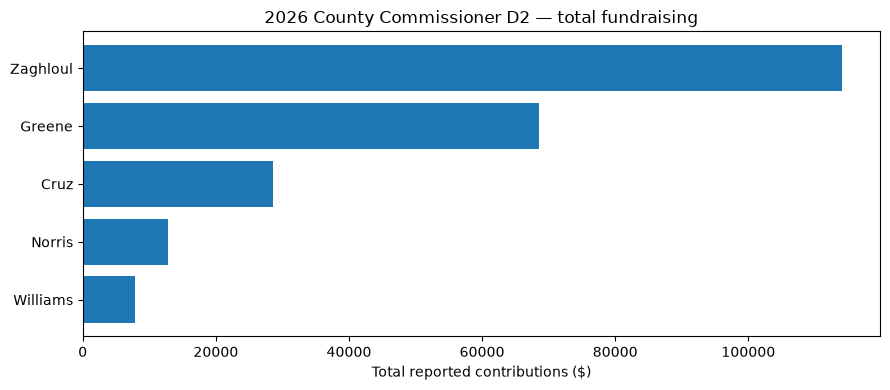

In [8]:
plot_table = candidate_summary.sort_values(
    "total_amount",
    ascending=True,
)

fig, ax = plt.subplots(
    figsize=(
        9,
        max(
            4,
            0.45 * len(plot_table),
        ),
    )
)

ax.barh(
    plot_table["candidate"],
    plot_table["total_amount"],
)

ax.set_xlabel("Total reported contributions ($)")
ax.set_ylabel("")
ax.set_title(
    "2026 County Commissioner D2 — total fundraising"
)

plt.tight_layout()
plt.show()


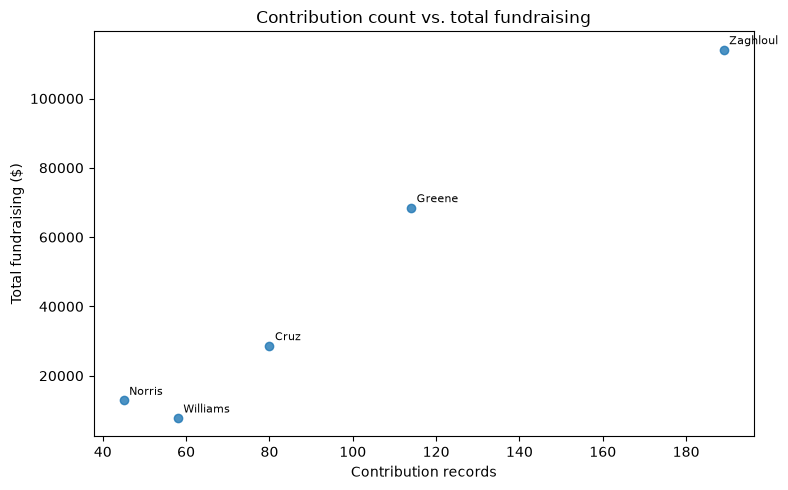

In [9]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.scatter(
    candidate_summary["contribution_count"],
    candidate_summary["total_amount"],
    alpha=0.8,
)

for _, row in candidate_summary.iterrows():
    ax.annotate(
        row["candidate"],
        (
            row["contribution_count"],
            row["total_amount"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xlabel("Contribution records")
ax.set_ylabel("Total fundraising ($)")
ax.set_title(
    "Contribution count vs. total fundraising"
)

plt.tight_layout()
plt.show()


## 9. Source audit

In [10]:
if AUDIT_PATH.exists():
    audit = pd.read_csv(
        AUDIT_PATH,
        low_memory=False,
    )

    duplicate_exports = audit.loc[
        to_bool(
            audit["is_exact_duplicate_export"]
        )
    ].copy()

    print(
        "Exact duplicate export rows:",
        len(duplicate_exports),
    )

    if len(duplicate_exports):
        display(duplicate_exports)


Exact duplicate export rows: 0


## 10. Export

In [11]:
candidate_path = (
    OUTPUT_DIR
    / "candidate_fundraising_summary.csv"
)

overall_path = (
    OUTPUT_DIR
    / "overall_fundraising_summary.csv"
)

type_path = (
    OUTPUT_DIR
    / "contribution_type_summary.csv"
)

candidate_summary.to_csv(
    candidate_path,
    index=False,
)

overall_summary.to_csv(
    overall_path,
    index=False,
)

contribution_type_summary.to_csv(
    type_path,
    index=False,
)

print("SAVED", candidate_path)
print("SAVED", overall_path)
print("SAVED", type_path)


SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2026/county_commissioner/candidate_fundraising_summary.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2026/county_commissioner/overall_fundraising_summary.csv
SAVED /Users/marcy/mggg/projects/Portland/portland-fundraising-support-analysis/data/processed/fundraising/2026/county_commissioner/contribution_type_summary.csv
